# ApexPlanet Software Pvt. Ltd. — Data Analytics Internship
## Task 2: Multivariate EDA & Static Dashboard Mock-Up
**Dataset:** `sales_dataset_python_analysis.csv`\
**Prepared by:** Brojo Mohan Dutta\
**Environment:** Jupyter Notebook / Python 3.x / Pandas, NumPy, Matplotlib, Seaborn

# 1. Setup & Data Load

In [1]:
#── Import Required Libraries ────────────────────────────────────────────────────────────
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

# Statistics
from scipy import stats


sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = "sales_dataset_python_analysis.csv"
df = pd.read_csv(DATA_PATH)

df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="%Y-%m-%d")

df = df[df["Order_Date"] < "2026-01-01"]

numeric_cols = ["Age", "Quantity", "Unit_Price", "Total_Sales"]
categorical_cols = ["Gender", "City", "Category", "Age_Group"]

# ── Global colour palette ────────────────────────────────────────────────────────────
category_colors = {"Electronics": "#234F5C","Education": "#E07A5F","Grocery": "#6A994E","Furniture": "#8D99AE","Fashion": "#7D6B91"}

city_colors = ["#B07AA1","#59A14F","#4E79A7","#EDC948","#76B7B2","#F28E2B","#FF9DA7","#E15759"]

age_colors = ["#D1E5F0","#92C5DE","#4393C3","#2166AC","#053061"]

gender_colors = ["#F06292","#2E8B99"]

print(df.shape)
df.info()

(995, 16)
<class 'pandas.core.frame.DataFrame'>
Index: 995 entries, 0 to 994
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          995 non-null    object        
 1   Order_Date        995 non-null    datetime64[ns]
 2   Customer_ID       995 non-null    object        
 3   Customer_Name     995 non-null    object        
 4   Age               995 non-null    int64         
 5   Age_Group         995 non-null    object        
 6   Gender            995 non-null    object        
 7   City              995 non-null    object        
 8   Product           995 non-null    object        
 9   Category          995 non-null    object        
 10  Quantity          995 non-null    int64         
 11  Unit_Price        995 non-null    float64       
 12  Total_Sales       995 non-null    float64       
 13  Order_Year        995 non-null    int64         
 14  Order_Month       995

# 2. Correlation Matrix — Numeric Variables

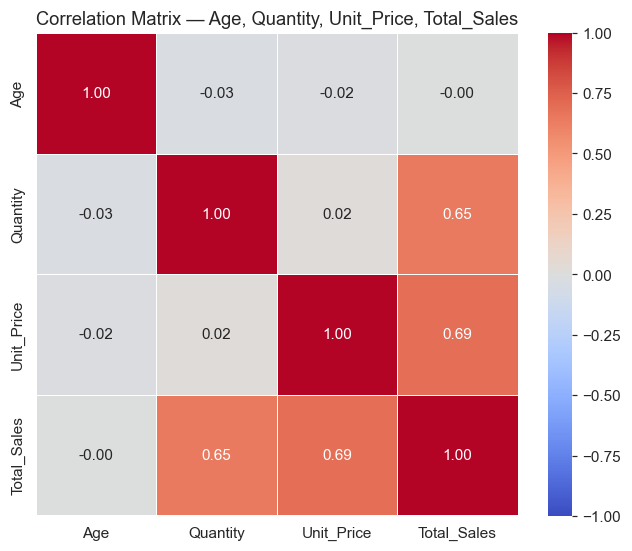

In [2]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation Matrix — Age, Quantity, Unit_Price, Total_Sales")
plt.tight_layout()
plt.savefig("01_chart_correlation_heatmap.png")
plt.show()

# 3. Pair Plot — Numeric Variables by Category

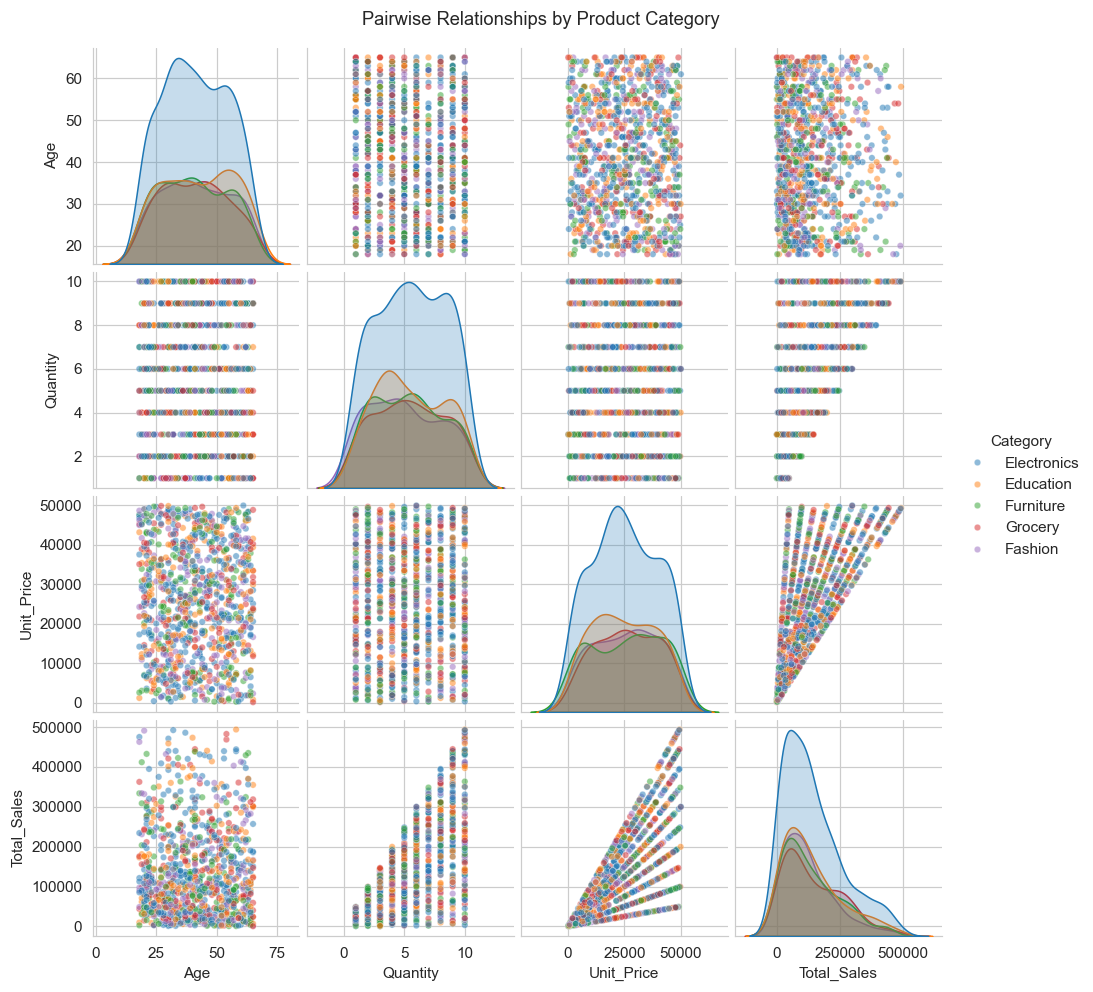

In [3]:
pair_grid = sns.pairplot(
    df[numeric_cols + ["Category"]],
    hue="Category",
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 18},
    height=2.2,
)
pair_grid.fig.suptitle("Pairwise Relationships by Product Category", y=1.02)
pair_grid.savefig("02_chart_pairplot_category.png")
plt.show()

# 4. Scatter Plot — Age vs. Total_Sales by Category

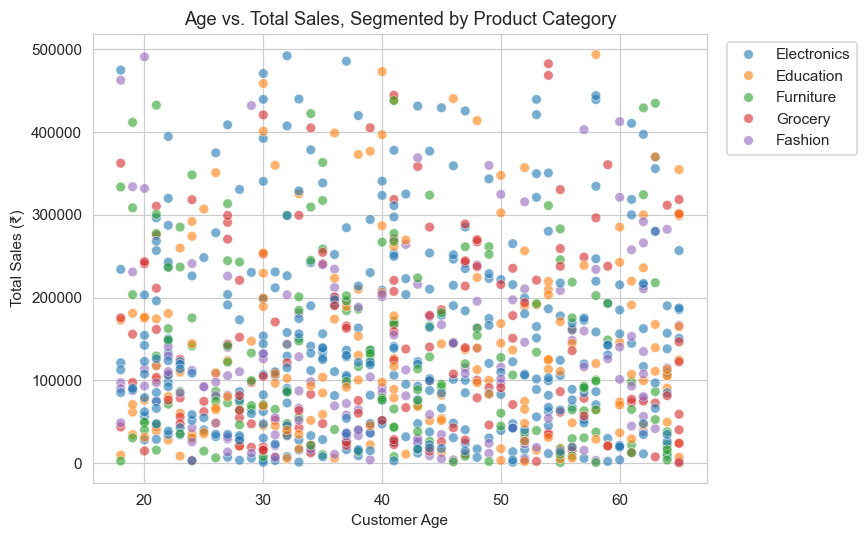

In [4]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Age", y="Total_Sales", hue="Category",
                 alpha=0.6, s=40, palette="tab10")
plt.title("Age vs. Total Sales, Segmented by Product Category")
plt.xlabel("Customer Age")
plt.ylabel("Total Sales (₹)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("03_chart_scatter_age_sales.png")
plt.show()

# 5. Scatter Plot — Quantity vs. Unit_Price by Gender

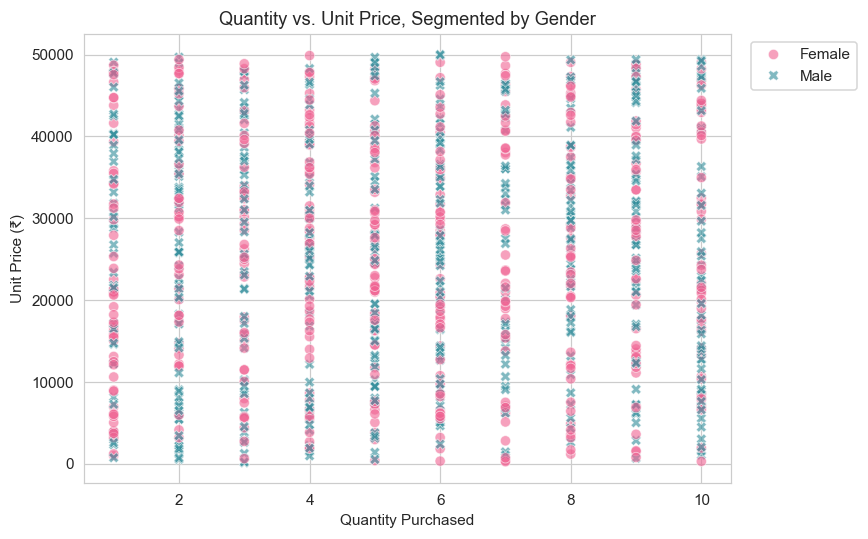

In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Quantity", y="Unit_Price", hue="Gender",
                 style="Gender", alpha=0.6, s=45, palette=gender_colors)
plt.title("Quantity vs. Unit Price, Segmented by Gender")
plt.xlabel("Quantity Purchased")
plt.ylabel("Unit Price (₹)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("04_chart_scatter_qty_price.png")
plt.show()

# 6. Heatmap — Average Total_Sales by City x Category

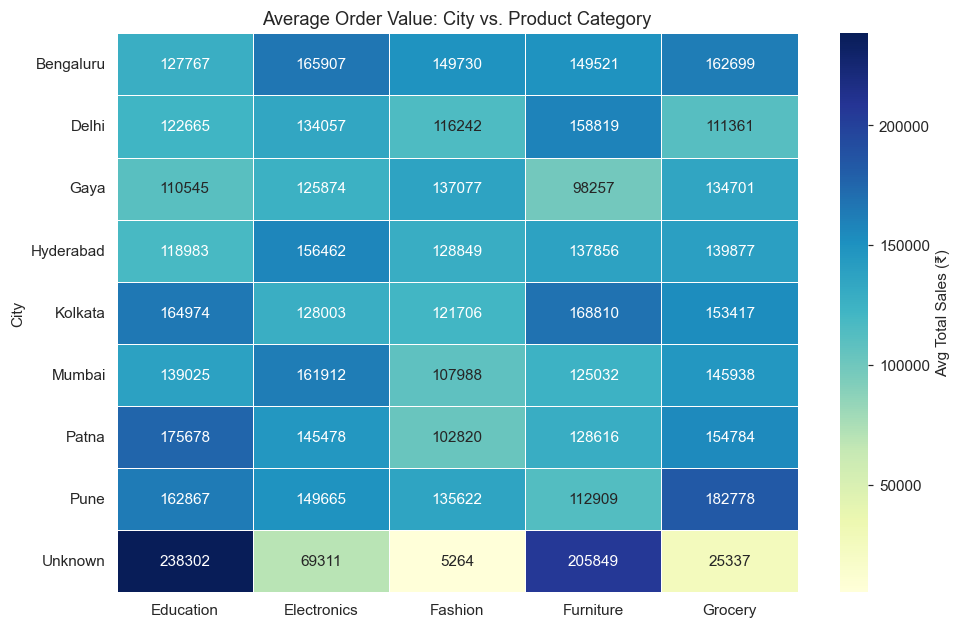

In [6]:
pivot_city_category = df.pivot_table(
    index="City", columns="Category", values="Total_Sales", aggfunc="mean"
).round(0)

plt.figure(figsize=(9, 6))
sns.heatmap(pivot_city_category, annot=True, fmt=".0f", cmap="YlGnBu",
            linewidths=0.5, cbar_kws={"label": "Avg Total Sales (₹)"})
plt.title("Average Order Value: City vs. Product Category")
plt.tight_layout()
plt.xlabel("")
plt.savefig("05_chart_heatmap_city_category.png")
plt.show()

# 7. Heatmap — Average Total_Sales by Age_Group x Category

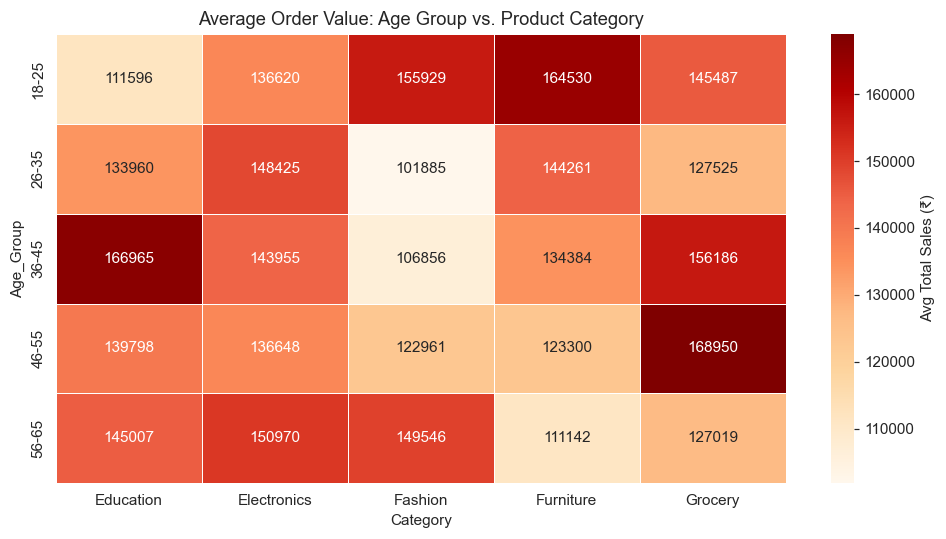

In [7]:
pivot_age_category = df.pivot_table(
    index="Age_Group", columns="Category", values="Total_Sales", aggfunc="mean"
).round(0)

age_order = ["18-25", "26-35", "36-45", "46-55", "56-65"]
pivot_age_category = pivot_age_category.reindex(
    [g for g in age_order if g in pivot_age_category.index]
)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot_age_category, annot=True, fmt=".0f", cmap="OrRd",
            linewidths=0.5, cbar_kws={"label": "Avg Total Sales (₹)"})
plt.title("Average Order Value: Age Group vs. Product Category")
plt.tight_layout()
plt.savefig("06_chart_heatmap_age_category.png")
plt.show()

# 8. Box Plot — Total_Sales Distribution by Category and Gender

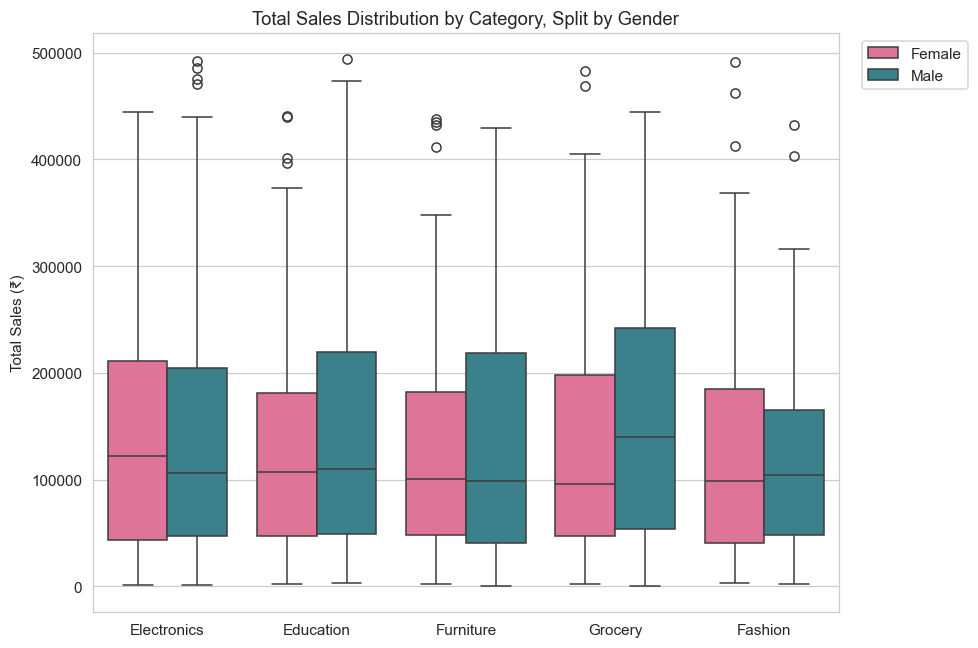

In [8]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="Category", y="Total_Sales", hue="Gender", palette=gender_colors)
plt.title("Total Sales Distribution by Category, Split by Gender")
plt.ylabel("Total Sales (₹)")
plt.xlabel("")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("07_chart_boxplot_category_gender.png")
plt.show()

# 9. Static Dashboard Mock-Up

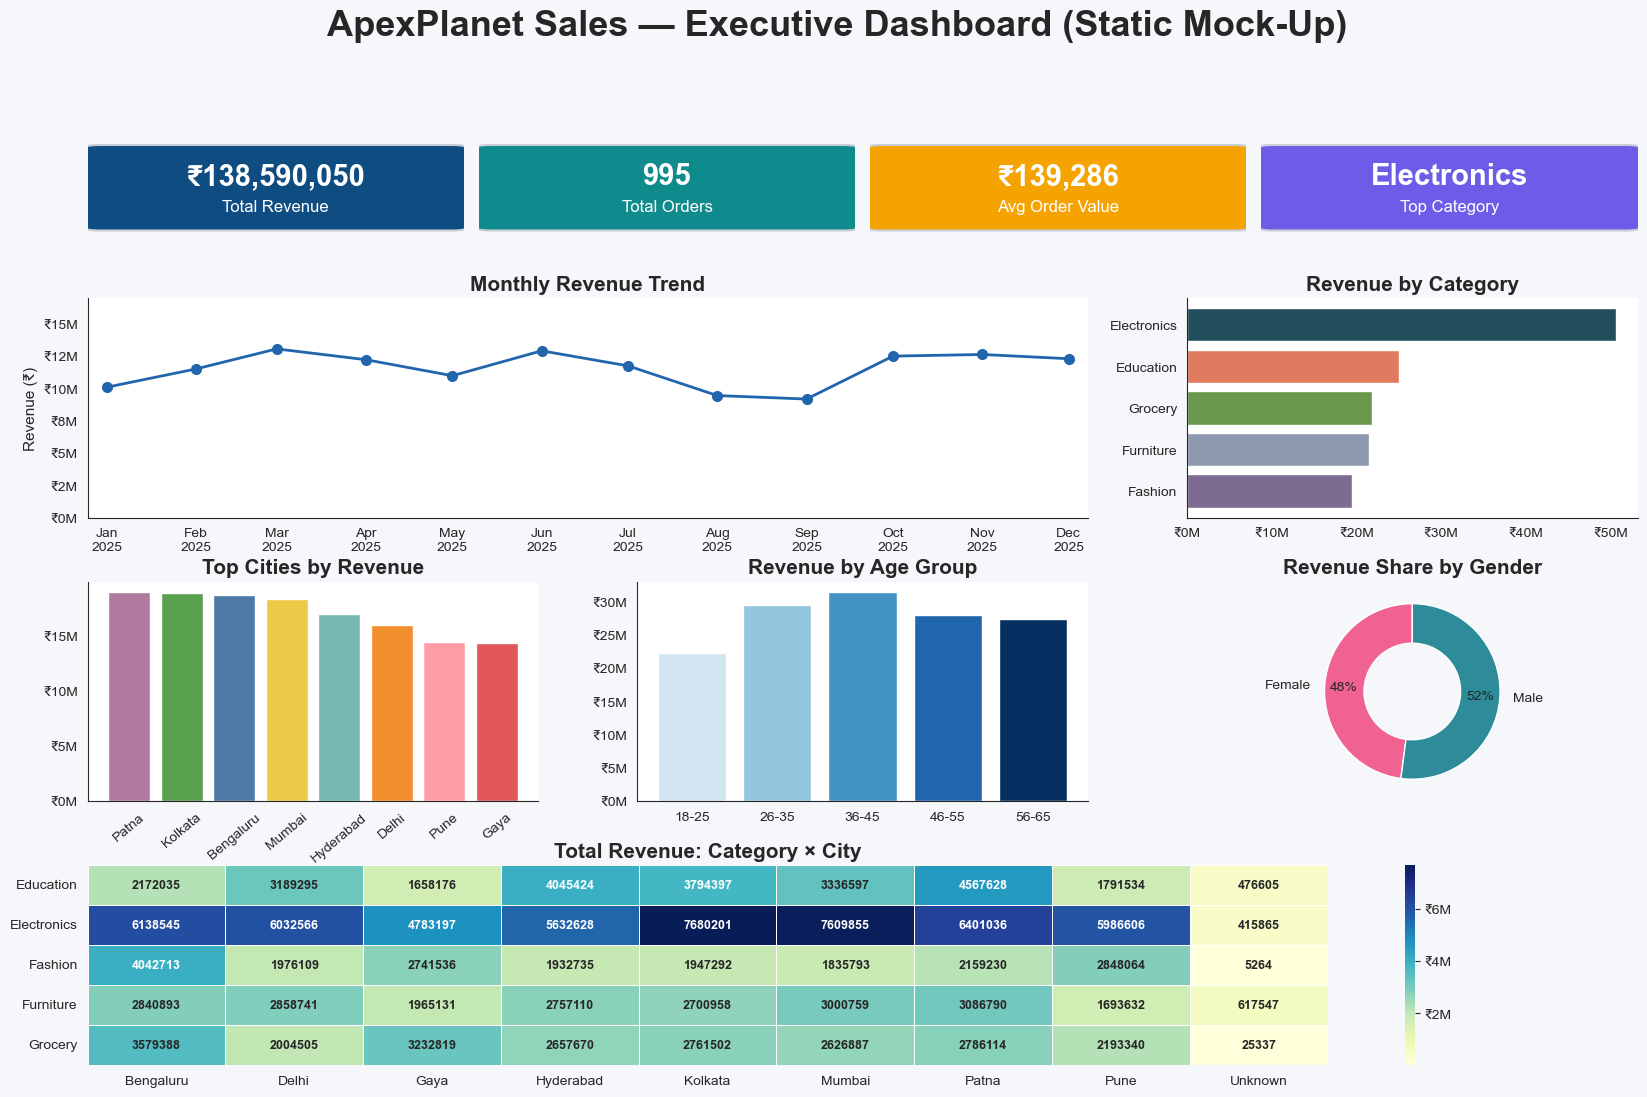

In [9]:
# ── Dashboard Theme ────────────────────────────────────────────────────────────
plt.style.use("default")
sns.set_style("white")

# ── KPIs ────────────────────────────────────────────────────────────
total_revenue = df["Total_Sales"].sum()
total_orders = df["Order_ID"].nunique()
avg_order_value = df["Total_Sales"].mean()
top_category = df.groupby("Category")["Total_Sales"].sum().idxmax()

fig = plt.figure(figsize=(20,12), facecolor="#F5F7FA")
outer = gridspec.GridSpec(4,3,height_ratios=[0.72,1.7,1.7,1.55],hspace=0.35,wspace=0.22)

def style_panel(ax):
    ax.set_facecolor("white")
    for s in ax.spines.values():
        s.set_color("#D9DDE3")
        s.set_linewidth(1)
    ax.grid(axis="y",alpha=.18)
    ax.set_axisbelow(True)

# ── KPI Cards ────────────────────────────────────────────────────────────
kpi_colors = ["#0F4C81","#0F8B8D","#F4A300","#6C5CE7"]
labels = ["Total Revenue","Total Orders","Avg Order Value","Top Category"]
values = [
    f"₹{total_revenue:,.0f}",
    f"{total_orders:,}",
    f"₹{avg_order_value:,.0f}",
    top_category
]

kpi_spec = gridspec.GridSpecFromSubplotSpec(1,4,subplot_spec=outer[0,:],wspace=.04)

for i in range(4):
    ax = fig.add_subplot(kpi_spec[0,i])
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_frame_on(False)

    card = FancyBboxPatch((0.01,0.06),0.98,0.88,boxstyle="round,pad=0.02,rounding_size=0.04",facecolor=kpi_colors[i],edgecolor="#C9CED6",
            linewidth=1.5)
    ax.add_patch(card)

    ax.text(0.5,0.62,values[i],ha="center",va="center",fontsize=21,fontweight="bold",color="white")
    ax.text(0.5,0.30,labels[i],ha="center",va="center",fontsize=12,color="white")
    
# ── Monthly Trend ────────────────────────────────────────────────────────────
ax1=fig.add_subplot(outer[1,:2])

monthly=(df.groupby(pd.Grouper(key="Order_Date",freq="MS"))["Total_Sales"].sum())

ax1.plot(monthly.index,monthly.values,color="#2166AC",linewidth=2,marker="o",markersize=7)

ax1.set_title("Monthly Revenue Trend",fontsize=15,fontweight="bold")

ax1.set_xlabel("")

ax1.set_ylabel("Revenue (₹)",fontsize=11)

ax1.set_xticks(monthly.index)

ax1.set_xticklabels(monthly.index.strftime("%b\n%Y"),rotation=0)

ax1.grid(False)

ax1.margins(x=0.02)

ax1.set_ylim(0, monthly.max()*1.3)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,pos:f"₹{x/1e6:.0f}M"))

# ── Revenue by Category ────────────────────────────────────────────────────────────
ax2=fig.add_subplot(outer[1,2])

cat=df.groupby("Category")["Total_Sales"].sum().sort_values()

colors=[category_colors[c] for c in cat.index]

ax2.barh(cat.index,cat.values,color=colors)

ax2.set_title("Revenue by Category",fontsize=15,fontweight="bold")

ax2.grid(False)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,pos:f"₹{x/1e6:.0f}M"))

# ── Top Cities ────────────────────────────────────────────────────────────
ax3=fig.add_subplot(outer[2,0])

city=(df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False).head(8))

bars=ax3.bar(city.index,city.values,color=city_colors)

ax3.set_title("Top Cities by Revenue",fontsize=15,fontweight="bold")

ax3.tick_params(axis="x",rotation=40)

ax3.grid(False)

ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,pos:f"₹{x/1e6:.0f}M"))

# ── Age Group ────────────────────────────────────────────────────────────
ax4=fig.add_subplot(outer[2,1])

age_order=["18-25","26-35","36-45","46-55","56-65"]

age=(df.groupby("Age_Group")["Total_Sales"].sum().reindex(age_order))

ax4.bar(age.index,age.values,color=age_colors)

ax4.set_title("Revenue by Age Group",fontsize=15,fontweight="bold")

ax4.grid(False)

ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)

ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,pos:f"₹{x/1e6:.0f}M"))

# ── Gender Donut ────────────────────────────────────────────────────────────
ax5=fig.add_subplot(outer[2,2])

gender=df.groupby("Gender")["Total_Sales"].sum()

ax5.pie(gender.values,labels=gender.index,autopct="%1.0f%%",startangle=90,radius=1,labeldistance=1.15,pctdistance=0.78, 
        colors=gender_colors,wedgeprops=dict(width=0.45,edgecolor="white"))

ax5.set_title("Revenue Share by Gender",fontsize=15,fontweight="bold")

# ── Heatmap ────────────────────────────────────────────────────────────
ax6=fig.add_subplot(outer[3,:])

pivot=df.pivot_table(index="Category",columns="City",values="Total_Sales",aggfunc="sum")

hm = sns.heatmap(pivot,cmap="YlGnBu",annot=True,fmt=".0f",linewidths=0.5,annot_kws={"fontsize":9, "fontweight":"bold"},cbar=True,ax=ax6)

cbar = hm.collections[0].colorbar
cbar.formatter = mticker.FuncFormatter(lambda x, pos: f"₹{x/1e6:.0f}M")
cbar.update_ticks()

plt.xlabel("")
plt.ylabel("")
ax6.set_title("Total Revenue: Category × City",fontsize=15,fontweight="bold")

# ── Dashboard Title ────────────────────────────────────────────────────────────
fig.suptitle("ApexPlanet Sales — Executive Dashboard (Static Mock-Up)",fontsize=26,fontweight="bold",y=0.99)

plt.savefig("dashboard_mockup.png",dpi=300,bbox_inches="tight")

plt.show()